# Exploratory Data Analysis and Data Visualization

In this assignment, you will continue working with the Craigslist car listings dataset.  
You’ll practice inspecting, cleaning, transforming, and analyzing the data with Pandas.  

For the purposes of this assignment, imagine that you are a data analyst working at large car insurance company like State Farm, Progressive, Geico, Amica, etc. Your company has purchased this
Craigslist data help in business operations. You've been tasked with beginning the process of understanding the data and its limitations. 

### Some Notes: 

- **AI use**: You may use AI to *ask questions* if you are stuck or need clarification. However, do not use AI code-completion or copy/paste code from AI. The purpose of this assignment is for you to gain fluency with matplotlib and advanced pandas operations by writing code yourself.  
- **Questions**: Look for cells marked with `Q:`. These contain questions for you to answer.  
- **Figures**: Save all your final plots to a subfolder called `figures/` with descriptive filenames.
- **Output**: Ensure your notebook runs top-to-bottom without errors. Remove stray debug code before submitting. When you're ready to submit, do a "restart and clear outputs", then run everything through sequentially. Your code cells will have consecutive numbers that way.

By the end of this assignment, you should feel comfortable with advanced pandas operations, creating publication-quality visualizations, and drawing insights from complex relationships in data.

---

## Part 0: Setup

In this section, you will import libraries and load the dataset. 
Make sure you have extracted the `car_listings.csv` file from the zip archive into your repository folder.




In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# We'll use these to make a smooth line on a scatterplot
from scipy.stats import linregress
from statsmodels.nonparametric.smoothers_lowess import lowess

# Create figures directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

# Set style for consistent plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [103]:
# Loading the data 
# Note, you'll need a copy of this CSV file in the same folder as your repo. 
# Or you can learn a bit about how to navigate folders and try to reference the file in a separate repo, 
# which is a bit tricky. It'll be something like this: pd.read_csv("../[Week 1 Assignment Folder on Your Machine]/car_listings.csv") 
listings = pd.read_csv("car_listings.csv")

# Handle column conversions
listings["time_posted"] = pd.to_datetime(listings["time_posted"], errors="coerce")
listings["year"] = pd.to_numeric(listings["year"], errors="coerce").astype("Int64")
listings["odometer"] = pd.to_numeric(listings["odometer"], errors="coerce").astype("Int64")
listings["post_id"] = pd.to_numeric(listings["post_id"], errors="coerce").astype("Int64")
listings["num_images"] = pd.to_numeric(listings["num_images"], errors="coerce").astype("Int64")
listings["price"] = pd.to_numeric(listings["price"], errors="coerce")
listings["latitude"] = pd.to_numeric(listings["latitude"], errors="coerce")
listings["longitude"] = pd.to_numeric(listings["longitude"], errors="coerce")


---

## Part 1: Data Quality and Missing Data Strategy


Before visualizing, let’s refine our approach to data quality.  
In this section, you will:

1. Drop duplicates and standardize string values.  
2. Remove clearly unrealistic outliers.  
3. Implement a targeted missing data strategy.  

This will ensure our analysis and visualizations reflect more accurate patterns.



In [104]:
# Drop duplicates from `listings` and put all strings in lowercase. Also, call `strip` on the
# strings. Take a moment to refresh your memory on how this function works. 

listings = listings.drop_duplicates()

string_vals = listings.select_dtypes(include="object").columns
for val in string_vals:
    listings[val] = listings[val].str.lower().str.strip()
    print(val)

url
location
name
make
model
title
paint
drive
cylinders
fuel
type
transmission
condition
vin
posting_body_text
title_text


In [105]:
listings.head

<bound method NDFrame.head of                                                       url     location  \
0       https://fargo.craigslist.org/cto/d/west-fargo-...        fargo   
1       https://chicago.craigslist.org/nwc/cto/d/des-p...      chicago   
2       https://chicago.craigslist.org/nch/cto/d/evans...      chicago   
3       https://chicago.craigslist.org/sox/cto/d/chica...      chicago   
4       https://chicago.craigslist.org/nwi/cto/d/scher...      chicago   
...                                                   ...          ...   
266811  https://chicago.craigslist.org/nwc/cto/d/verno...      chicago   
266812  https://chicago.craigslist.org/sox/cto/d/chica...      chicago   
266813  https://chicago.craigslist.org/chc/cto/d/frank...      chicago   
266814  https://chicago.craigslist.org/nwc/cto/d/liber...      chicago   
266815  https://minneapolis.craigslist.org/ram/cto/d/w...  minneapolis   

           post_id               time_posted  \
0       7787882335 2024-09-25 09:

In [106]:
# Look at the output of describe, and come up with some reasonable, but not overly restrictive
# cutoffs on the numeric values odometer, price, year. 
# For odometer and year, replace values outside that range with the max or min, depending on 
# which way the value is an outlier. For price, replace extreme values with missing values.

listings.describe()

,post_id,year,odometer,price,num_images,latitude,longitude
count,258169.0,254061.0,254025.0,247319.000000,247599.0,247407.000000,247407.000000
mean,7770093052.01781,2009.261051,152200.424423,9587.873079,11.300542,42.392584,-90.331420
std,67902031.874388,6.299463,161018.559775,10289.281344,5.964928,3.041973,5.375154
min,7525960928.0,1990.0,0.0,500.000000,1.0,-72.895538,-155.901311
25%,7717790223.0,2005.0,100000.0,3650.000000,7.0,41.602800,-93.304676
50%,7775958355.0,2010.0,142875.0,6000.000000,10.0,42.113900,-89.452600
75%,7829000314.0,2014.0,185000.0,11500.000000,15.0,44.674900,-87.928700
max,7878823161.0,2023.0,10000000.0,100000.000000,24.0,76.785337,0.000000


In [52]:
listings["year"] = listings["year"].clip(lower=1996, upper=2023)
listings["odometer"] = listings["odometer"].clip(lower=1000, upper=300000)

In [53]:
listings.loc[(listings["price"]<1000) | (listings["price"] > 50000), "price"] = pd.NA

In [54]:
make_year_median = listings.groupby("make")["year"].median().sort_values(ascending=False)
print(make_year_median.head(20))

make
lucid           2023.0
rivian          2023.0
polestar        2021.5
tesla           2019.0
alfa romeo      2018.0
maserati        2015.0
freightliner    2014.0
genesis         2013.0
kia             2013.0
fiat            2013.0
hyundai         2012.0
audi            2012.0
ram             2012.0
volkswagen      2012.0
nissan          2012.0
rolls-royce     2011.5
mini            2011.0
porsche         2011.0
land rover      2011.0
dodge           2011.0
Name: year, dtype: Float64


In [107]:
overall_median_year = listings["year"].median()
print("Overall median year:", overall_median_year)

Overall median year: 2010.0


Q:  Why might it be better to fill missing `year` values using the median by make instead of the overall median?  
A:  <!-- Your reply here. --> From above, we can see that newer brands like Lucid and Rivian have median years of 2023, while older brands like Dodge and Land Rover are from around 2011. The overall median is 2010, which is much lower than the median for new brands. If we filled in the missing years using the overall median, new cars would appear unrealistically old. Using the median by filling missing values in a way that is realistic for each specific brand.

Q: What are the risks of the outlier removal approach we used above?  
A:  <!-- Your reply here. --> Clipping or marking extreme values might remove legitimate data and reduce variability, which can affect analysis or models. The limits are based on mean, standard deviation, and some domain knowledge, but they aren’t strict rules, so some valid values could be misclassified as outliers.

Q: Why might it make sense to replace extreme values of price with missing values rather than truncated values?   
A:  <!-- Your reply here. --> Extreme prices are often errors or unrealistic entries. Replacing them with missing values avoids giving false information, while truncating would assign a number that might still be wrong. Missing values can be handled carefully later, keeping the data more accurate.

### Part 2: Grouping Operations and Categorical Data

In this section, we'll first convert locations, makes, and models to categorical variables, comparing how much memory `listings` takes before and after. We'll then restrict our data to two make/model combinations, and perform some grouping operations. 


In [108]:
# Let's add car age to the data set
listings["car_age"] = 2025 - listings["year"]

# Let's calculate the current memory usage
memory_used = listings.memory_usage(deep=True).sum()
print(f"Memory usage: {memory_used/(1024*1024):.2f} MB")

Memory usage: 409.95 MB


In [109]:
# Covert make, model, and location to categorical variables. After the conversion, do
# a value counts that shows the top 20 combinations of location-make-model. The highest combo
# should be Chicago Toyota Camrys

listings[["location", "make", "model"]] = listings[["location", "make", "model"]].astype("category")
top_combinations = (
    listings.groupby(["location", "make", "model"], observed = True)
    .size()
    .sort_values(ascending=False)
    .head(20)
)
print(top_combinations)


location     make       model    
chicago      toyota     camry        2004
             nissan     r            1757
minneapolis  ford       f150         1695
chicago      honda      accord       1582
             ford       f150         1521
             honda      odyssey      1367
             nissan     altima       1213
minneapolis  toyota     camry        1196
chicago      ford       escape       1195
             honda      civic        1181
minneapolis  chevrolet  silverado    1172
             honda      accord       1084
chicago      chevrolet  equinox       999
             bmw        m             905
             toyota     corolla       887
kansascity   ford       f150          881
stlouis      ford       f150          838
chicago      honda      cr            828
minneapolis  ram        1500          826
chicago      chevrolet  malibu        806
dtype: int64


In this next cell, select two make/model combination. I recommend chosing two vehicles that might attract different types of buyers. Ensure that your make/model combination has at least 250 listings across all locations. Call your data set `listings_subset`.

You'll use `listings_subset` for the rest of this assignment.

In [110]:
# build listings_subset here
combos = [("bmw", "m"),
         ("toyota", "camry")]
listings_subset = listings[
    ((listings["make"] == "bmw") & (listings["model"] == "m")) |
    ((listings["make"] == "toyota") & (listings["model"] == "camry"))
]
listings_subset.head()

,url,location,post_id,time_posted,name,make,model,year,odometer,title,...,transmission,condition,vin,price,posting_body_text,title_text,num_images,latitude,longitude,car_age
24,https://stlouis.craigslist.org/cto/d/saint-lou...,stlouis,7786325429,2024-09-19 18:40:34+00:00,toyota camry le,toyota,camry,2007,162000,clean,...,automatic,excellent,NaN,4995.0,qr code link to this post\n\n\n\n2007 toyota c...,2007 toyota camry,12,38.629500,-90.334200,18
53,https://fargo.craigslist.org/cto/d/battle-lake...,fargo,7789456544,2024-09-30 18:33:01+00:00,toyota camry,toyota,camry,2008,192379,clean,...,automatic,excellent,NaN,5900.0,qr code link to this post\n\n\n2008 toyota cam...,2008 toyota camry,8,46.321500,-95.728000,17
184,https://minneapolis.craigslist.org/hnp/cto/d/m...,minneapolis,7878594032,2025-09-02 18:25:35+00:00,toyota camry,toyota,camry,2005,174000,clean,...,automatic,excellent,NaN,2800.0,qr code link to this post\n\n\ngood condition ...,toyota camry,11,45.063900,-93.302200,20
190,https://chicago.craigslist.org/chc/cto/d/chica...,chicago,7878628129,2025-09-02 21:36:11+00:00,toyota camry,toyota,camry,2012,149000,clean,...,automatic,like new,4t4bf1fk0cr177779,7995.0,qr code link to this post\n\n\nvin. 4t4bf1fk0c...,2012 toyota camry le,20,41.985631,-87.699357,13
229,https://minneapolis.craigslist.org/hnp/cto/d/e...,minneapolis,7878636174,2025-09-02 22:46:47+00:00,bmw x5 xdrive 50i,bmw,m,2012,116071,clean,...,automatic,good,NaN,5500.0,qr code link to this post\n\n\nhard to find bm...,2012 bmw x5 50i xdrive with 3rd row 7 passenger,22,44.834200,-93.438900,13


In [111]:
listings_subset["model"].value_counts()

model
camry                  4881
m                      2033
q7                        0
promaster cargo van       0
promaster city            0
                       ... 
ex                        0
excursion                 0
expedition                0
expedition el             0
zx2                       0
Name: count, Length: 1041, dtype: int64

We'll now carry out some of the examples from our reading on this data set, particular the materials from chapter 10 (with some 5.3 thrown in).

In [112]:
# Calculate the average price for each of your make/models by location
# Print those values out and build one chart for each make/model.
average_price = (
    listings_subset
    .groupby(["model", "make", "location"], observed=True)["price"]
    .mean()
    .reset_index() 
)

print(average_price)

    model    make     location         price
0   camry  toyota     appleton   6823.000000
1   camry  toyota      chicago   5980.529954
2   camry  toyota    desmoines   7286.192982
3   camry  toyota       duluth   6578.354430
4   camry  toyota        fargo   7596.326531
5   camry  toyota  grandrapids   6070.567010
6   camry  toyota   kansascity   6099.252747
7   camry  toyota      madison   6063.495146
8   camry  toyota    milwaukee   5667.370558
9   camry  toyota  minneapolis   6733.057070
10  camry  toyota        omaha   8054.934066
11  camry  toyota      stlouis   6712.759259
12      m     bmw     appleton  14050.344828
13      m     bmw      chicago  11244.752577
14      m     bmw    desmoines  16011.431818
15      m     bmw       duluth   9331.250000
16      m     bmw        fargo   9100.454545
17      m     bmw  grandrapids   9593.400000
18      m     bmw   kansascity  10901.191919
19      m     bmw      madison   9866.644737
20      m     bmw    milwaukee  10959.664384
21      m 

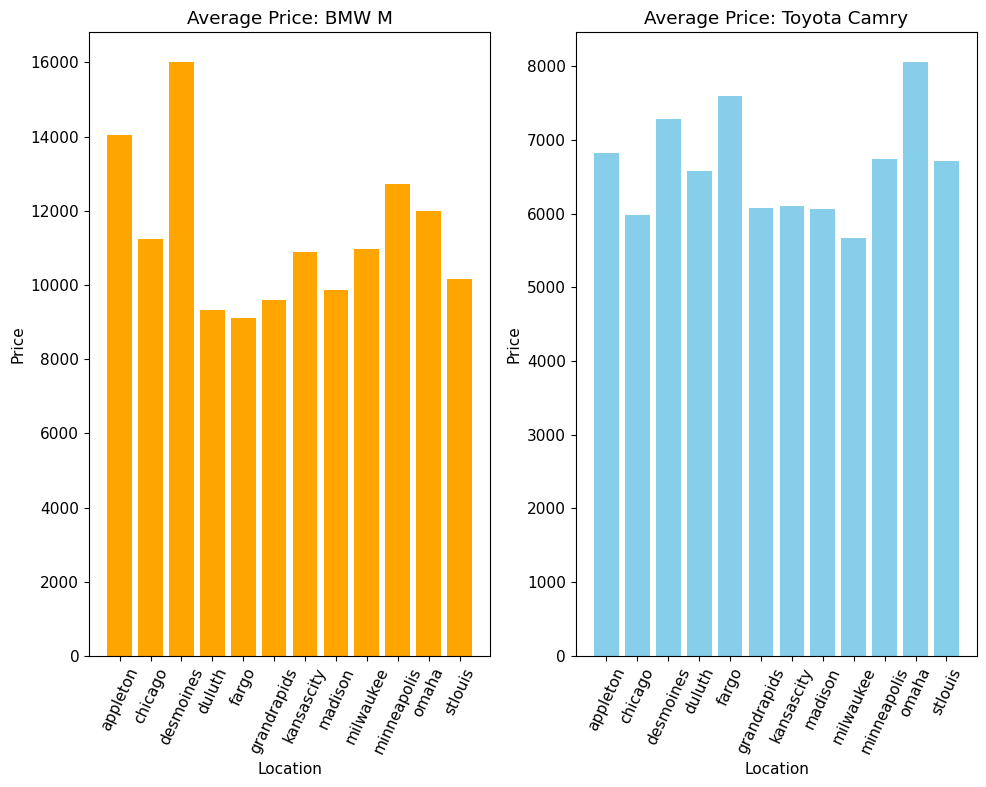

In [113]:
# Save your two charts into your `figures` folder. I typically use .png file types
# but feel free to play around with the options. 

bmw_data = average_price[average_price["model"] == "m"]
toyota_data = average_price[average_price["model"] == "camry"]

fig, axes = plt.subplots(1, 2, figsize=(10, 8))


axes[0].bar(bmw_data["location"], bmw_data["price"], color="orange")
axes[0].set_title("Average Price: BMW M")
axes[0].set_xlabel("Location")
axes[0].set_ylabel("Price")
axes[0].tick_params(axis='x', rotation=65)


axes[1].bar(toyota_data["location"], toyota_data["price"], color="skyblue")
axes[1].set_title("Average Price: Toyota Camry")
axes[1].set_xlabel("Location")
axes[1].set_ylabel("Price")
axes[1].tick_params(axis='x', rotation=65)

plt.tight_layout()
plt.show()

fig.savefig("figures/average_price_charts.png", dpi=300, bbox_inches='tight')

Q: What are the main things you notice about the prices of your cars by location?

A: <!-- Your Answer Here --> BMW M cars are much more expensive, ranging $9K-$13K vs Toyota Camrys at $5.5K-$8K, which makes sense given BMW M is luxury/performance. Prices vary significantly by location for both cars. Appleton has the highest BMW M prices, while Omaha tops the Camry market.

In [114]:
# Find the three-year range that has the most vehicles for both your make models. Repeat the 
# price-by-location analysis and plots for those three years. Don't save these plots, as
# they are more exploratory.
year_counts = listings_subset.groupby(["model", "year"],observed=True).size().reset_index(name="count")

In [115]:
camry_years = year_counts[year_counts["model"] == "camry"].sort_values("year")
print(camry_years.head())
bmw_years = year_counts[year_counts["model"] == "m"].sort_values("year")
print(bmw_years.head())

   model  year  count
0  camry  1990      8
1  camry  1991      3
2  camry  1992      4
3  camry  1993      8
4  camry  1994      5
   model  year  count
34     m  1990      2
35     m  1991      6
36     m  1992      4
37     m  1993      4
38     m  1994      9


In [116]:
camry_years["rolling_3yr"] = camry_years["count"].rolling(3).sum()
print(camry_years)
bmw_years["rolling_3yr"] = bmw_years["count"].rolling(3).sum()
print(bmw_years)

    model  year  count  rolling_3yr
0   camry  1990      8          NaN
1   camry  1991      3          NaN
2   camry  1992      4         15.0
3   camry  1993      8         15.0
4   camry  1994      5         17.0
5   camry  1995     16         29.0
6   camry  1996     22         43.0
7   camry  1997     36         74.0
8   camry  1998     83        141.0
9   camry  1999    128        247.0
10  camry  2000    129        340.0
11  camry  2001    169        426.0
12  camry  2002    211        509.0
13  camry  2003    336        716.0
14  camry  2004    225        772.0
15  camry  2005    293        854.0
16  camry  2006    203        721.0
17  camry  2007    553       1049.0
18  camry  2008    270       1026.0
19  camry  2009    419       1242.0
20  camry  2010    308        997.0
21  camry  2011    337       1064.0
22  camry  2012    243        888.0
23  camry  2013    178        758.0
24  camry  2014    208        629.0
25  camry  2015    108        494.0
26  camry  2016     84      

In [117]:
camry_max_idx = camry_years["rolling_3yr"].idxmax()
bmw_max_idx = bmw_years["rolling_3yr"].idxmax()

In [118]:
camry_range = camry_years.loc[camry_max_idx-2 : camry_max_idx, "year"].values
bmw_range = bmw_years.loc[bmw_max_idx-2 : bmw_max_idx, "year"].values
print("Camry most common 3-year range:", camry_range)
print("BMW M most common 3-year range:", bmw_range)

Camry most common 3-year range: <IntegerArray>
[2007, 2008, 2009]
Length: 3, dtype: Int64
BMW M most common 3-year range: <IntegerArray>
[2011, 2012, 2013]
Length: 3, dtype: Int64


In [119]:
camry_subset = listings_subset[
    (listings_subset["model"] == "camry") &
    (listings_subset["year"].between(camry_range[0], camry_range[-1]))
]

bmw_subset = listings_subset[
    (listings_subset["model"] == "m") &
    (listings_subset["year"].between(bmw_range[0], bmw_range[-1]))
]

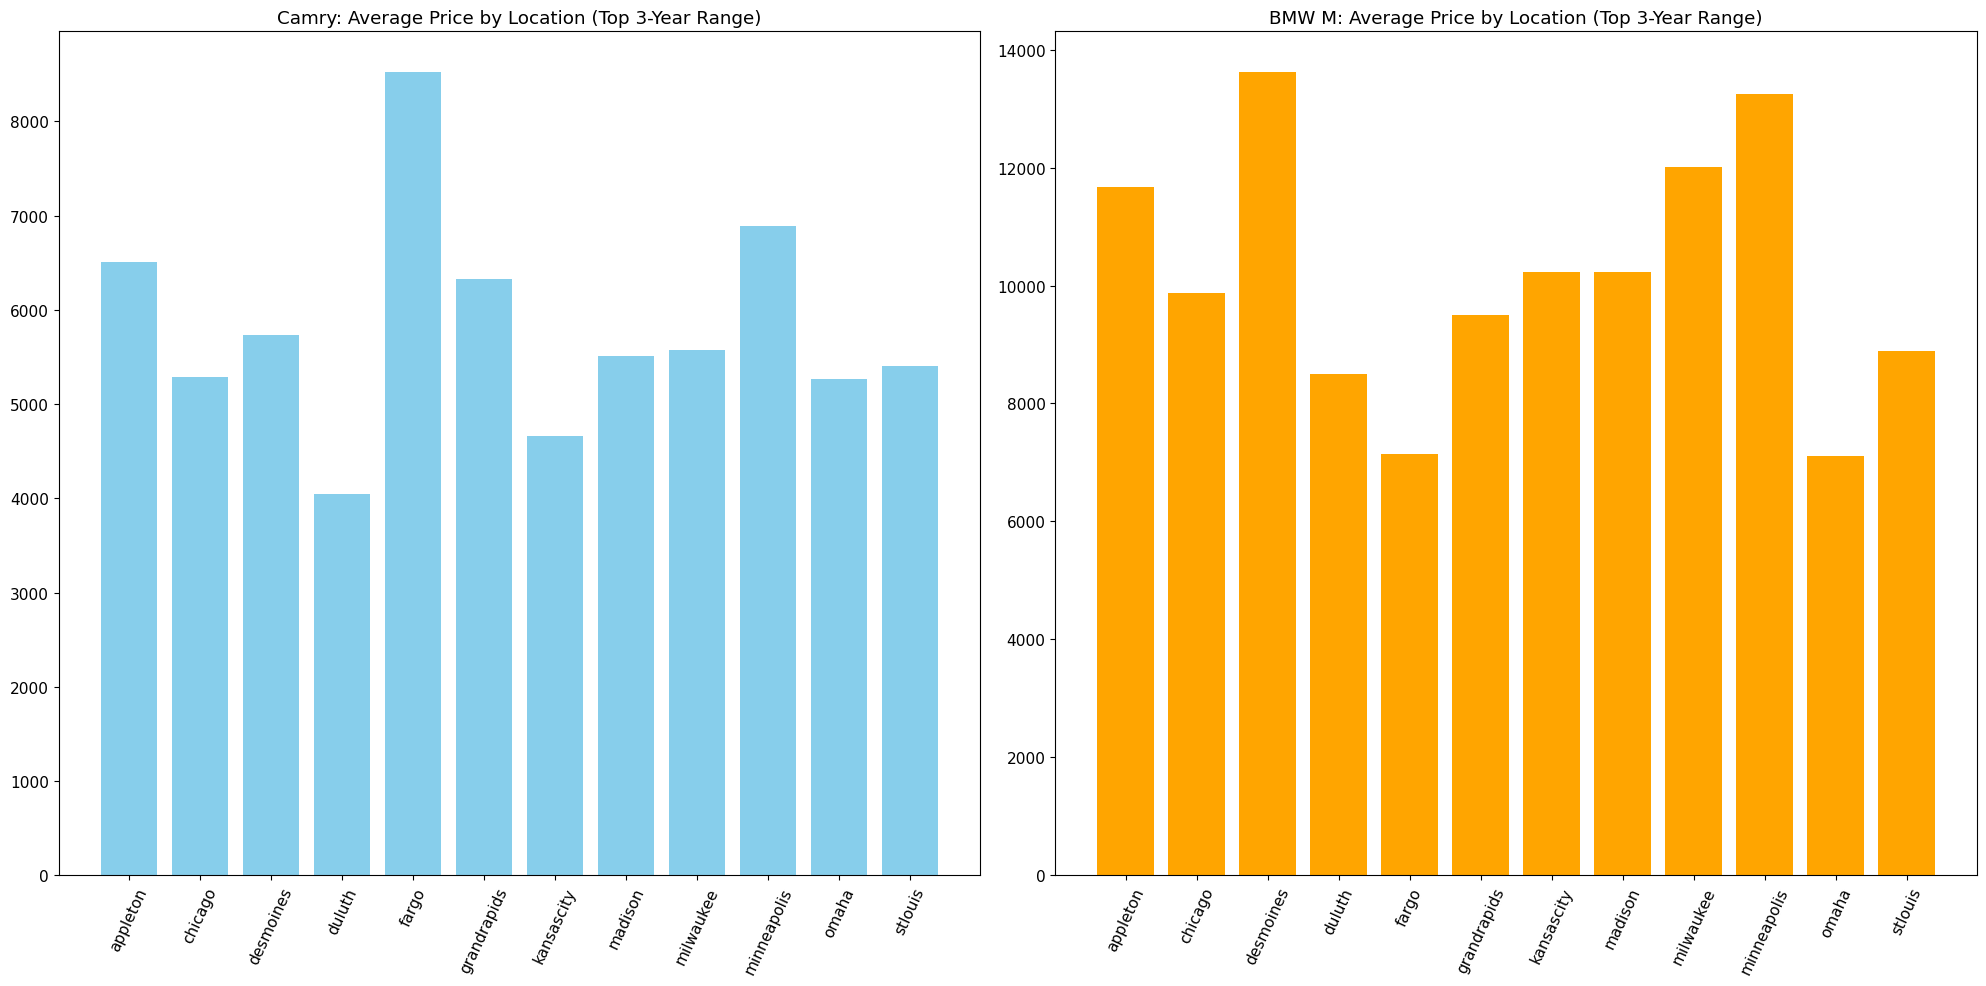

In [120]:
avg_price_3yr = pd.concat([camry_subset, bmw_subset])
avg_price_3yr = avg_price_3yr.groupby(["model", "location"], observed=True)["price"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].bar(avg_price_3yr[avg_price_3yr["model"]=="camry"]["location"],
            avg_price_3yr[avg_price_3yr["model"]=="camry"]["price"], color="skyblue")
axes[0].set_title("Camry: Average Price by Location (Top 3-Year Range)")
axes[0].tick_params(axis='x', rotation=65)

axes[1].bar(avg_price_3yr[avg_price_3yr["model"]=="m"]["location"],
            avg_price_3yr[avg_price_3yr["model"]=="m"]["price"], color="orange")
axes[1].set_title("BMW M: Average Price by Location (Top 3-Year Range)")
axes[1].tick_params(axis='x', rotation=65)

plt.tight_layout()
plt.show()

Q: What changed when you restricted your date range? 

A: <!-- Your Answer Here --> Restricting the date range focused only on the years with the most vehicles, which changed the average price values slightly and highlighted which locations had the highest concentration of listings during that period.

---

Below I have a function for you that will return the interquartile range (IQR) of a column for use in a groupby operation. Create your own function that summarizes an aspect of the data that might be interesting when viewed across locations.

In [121]:
# The below function returns the inter-quartile range of a column
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

# write your function here
#returns the coefficient of variation to calculate price, mileage spread
def variability(series):
    if series.mean() == 0:
        return 0  
    return series.std() / series.mean()



In [122]:
functions = ["count", "mean", "max", iqr, variability]  #Add your function

# For each make and model, separately, apply each of the above functions to price
# and odometer, grouped by location
bmw_stats = listings_subset[listings_subset["model"] == "m"].groupby("location", observed=True)[["price", "odometer"]].agg(functions)

toyota_stats = listings_subset[listings_subset["model"] == "camry"].groupby("location", observed=True)[["price", "odometer"]].agg(functions)

print("BMW M stats by location:")
print(bmw_stats)

print("\nToyota Camry stats by location:")
print(toyota_stats)


BMW M stats by location:
            price                                               odometer  \
            count          mean       max       iqr variability    count   
location                                                                   
appleton       29  14050.344828   52900.0   8000.00    0.744616       29   
chicago       873  11244.752577   85800.0   8300.00    0.854586      905   
desmoines      44  16011.431818   91150.0  11901.00    1.216426       44   
duluth         16   9331.250000   20800.0   2200.00    0.422419       16   
fargo          11   9100.454545   19750.0   6850.00    0.677018       11   
grandrapids    65   9593.400000   37500.0   8250.00    0.829485       66   
kansascity     99  10901.191919   66000.0   7750.00    0.929619      103   
madison        76   9866.644737   39000.0   7943.75    0.745153       77   
milwaukee     146  10959.664384   77500.0   6750.00    0.996965      152   
minneapolis   421  12718.453682  100000.0   9000.00    1.039440

Q: Write a bit about what you notice when viewing the data with these aggregations. Imagine you're responding to a colleague who asks "In these Midwestern cities, how do those types of vehicles vary in price and mileage?" Write more for this answer than you do for some of the short questions I've asked you.

A: <!-- Your answer here -->In these Midwestern cities, BMW M models have higher prices and wider variation in both price and mileage compared to Camrys, which is obvious. Average prices range roughly from $9,100 in Fargo to over $13,100 in Appleton. Cities like Omaha and Kansas City show the largest price spreads, indicating some cars are far above or below the average, while smaller cities such as Fargo and Duluth have more consistent pricing. Mileage generally clusters around moderate odometer readings, but the variability shows that some cities have a few high-mileage outliers.

For Toyota Camrys, prices are lower overall, usually between $5,700 and $8,000. Mileage also varies, with some cars having low miles and others much higher, especially in smaller cities like Duluth and Appleton, likely because there are both older and newer cars. Bigger cities like Chicago and Minneapolis have more listings, so both prices and mileage are a bit more consistent, though some variation still exists.

---


### Part 2: Bivariate Relationships & Smoothing

Build four scatterplots, two for each make/model combination. For each combination, make a plot of age versus price and odometer versus price.

/var/folders/cz/lb9k3krn429_0k0v335n5kbw0000gn/T/ipykernel_5175/2204825665.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  listings_subset['age'] = 2025 - listings_subset['year']


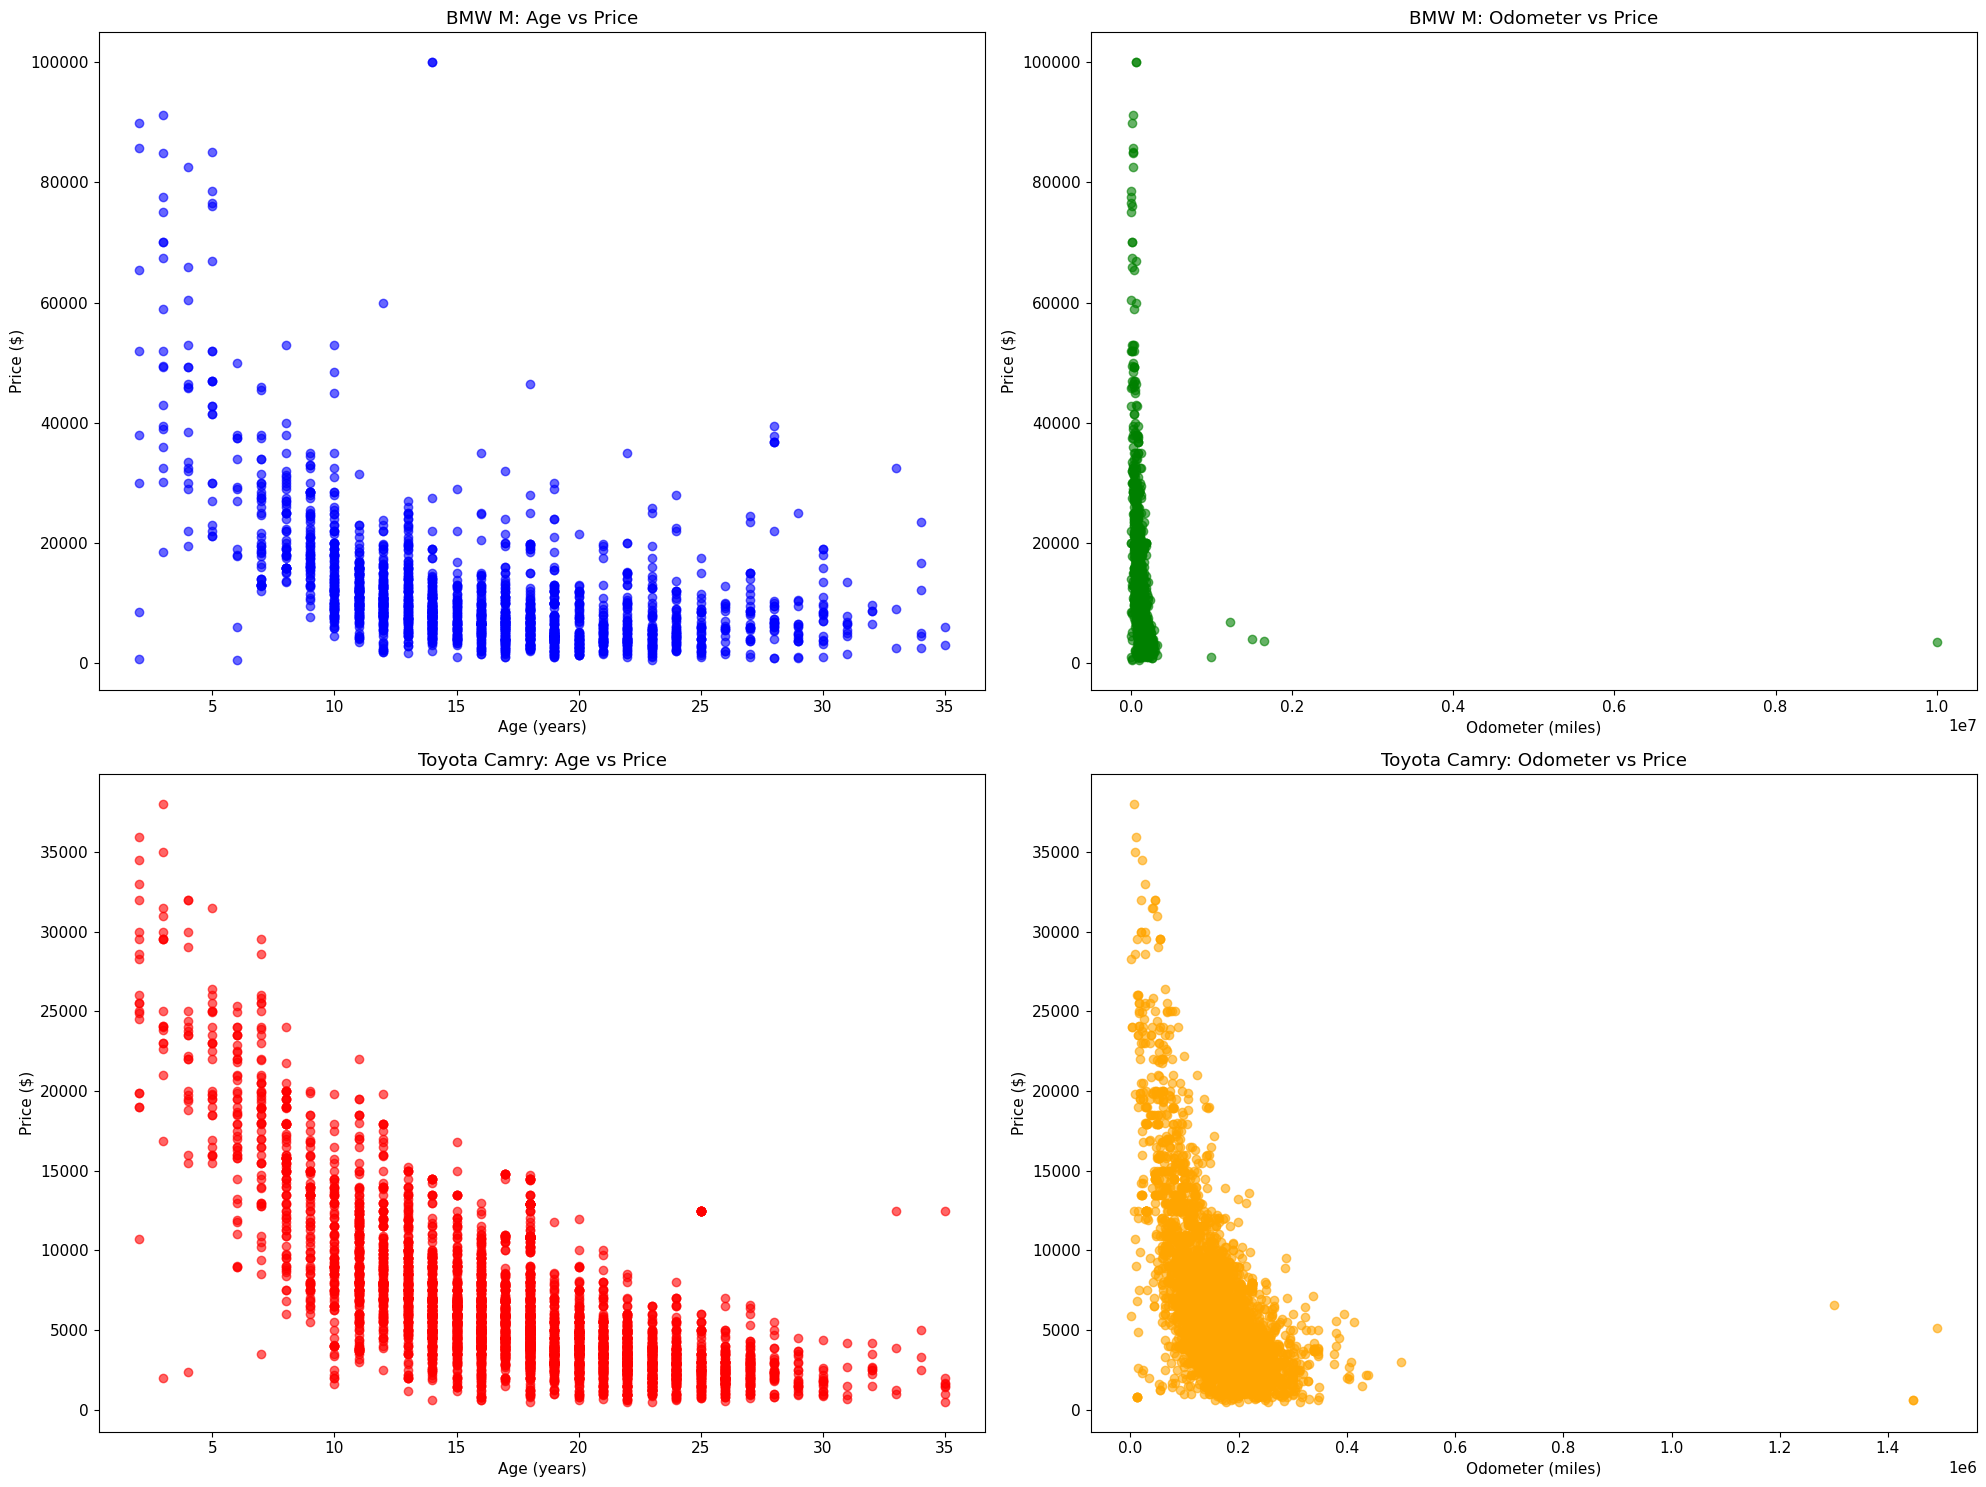

In [138]:
# Plotting code here.
bmw = listings_subset[listings_subset["model"] == "m"]
camry = listings_subset[listings_subset["model"] == "camry"]

listings_subset['age'] = 2025 - listings_subset['year']

fig, axes = plt.subplots(2, 2, figsize=(20,15))

axes[0, 0].scatter(bmw["age"], bmw["price"], alpha=0.6, color='blue')
axes[0, 0].set_title("BMW M: Age vs Price")
axes[0, 0].set_xlabel("Age (years)")
axes[0, 0].set_ylabel("Price ($)")

axes[0, 1].scatter(bmw["odometer"], bmw["price"],alpha=0.6, color='green')
axes[0, 1].set_title("BMW M: Odometer vs Price")
axes[0, 1].set_xlabel("Odometer (miles)")
axes[0, 1].set_ylabel("Price ($)")

axes[1, 0].scatter(camry["age"], camry["price"], alpha=0.6, color='red')
axes[1, 0].set_title("Toyota Camry: Age vs Price")
axes[1, 0].set_xlabel("Age (years)")
axes[1, 0].set_ylabel("Price ($)")

axes[1, 1].scatter(camry["odometer"], camry["price"], alpha=0.6, color='orange')
axes[1, 1].set_title("Toyota Camry: Odometer vs Price")
axes[1, 1].set_xlabel("Odometer (miles)")
axes[1, 1].set_ylabel("Price ($)")

plt.tight_layout()
fig.savefig("figures/average_price_charts.png", dpi=300, bbox_inches='tight')
plt.show()

Sometimes it's nice to add linear and smooth lines to a chart in order to better understand the relationshiop. Consider this next piece optional. If you have time, I think it will be a good skill to learn, but if you're pressed for time, skip it and you'll see it in the solution. I've 
attempted to give you enough code to get it working. You may have to adapt it to your specific code, including filling in a value for `model1` below.


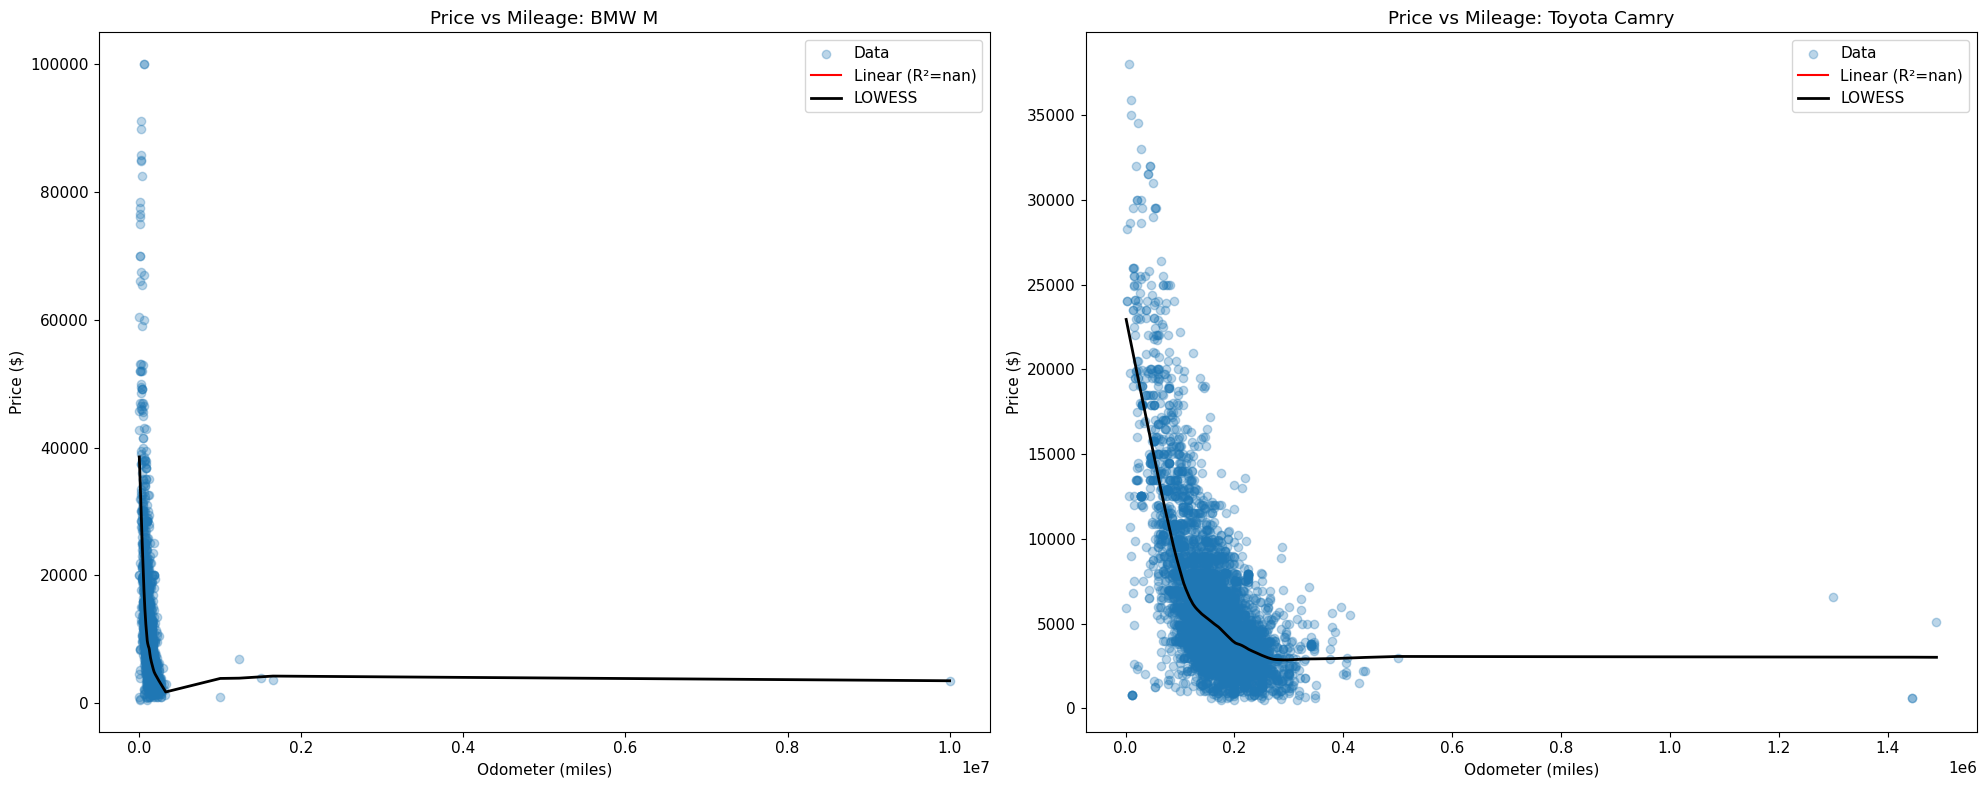

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))  # 2 plots side by side

x_bmw = listings_subset.loc[listings_subset["model"] == "m", "odometer"]
y_bmw = listings_subset.loc[listings_subset["model"] == "m", "price"]

axes[0].scatter(x_bmw, y_bmw, alpha=0.3, label='Data')

slope, intercept, r_value, p_value, std_err = linregress(x_bmw, y_bmw)
line = slope * x_bmw + intercept
axes[0].plot(x_bmw, line, 'r-', label=f'Linear (R²={r_value**2:.3f})')

lowess_results = lowess(y_bmw, x_bmw, frac=0.3)
axes[0].plot(lowess_results[:, 0], lowess_results[:, 1], 'k-', linewidth=2, label='LOWESS')

axes[0].set_xlabel('Odometer (miles)')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price vs Mileage: BMW M')
axes[0].legend()


x_camry = listings_subset.loc[listings_subset["model"] == "camry", "odometer"]
y_camry = listings_subset.loc[listings_subset["model"] == "camry", "price"]

axes[1].scatter(x_camry, y_camry, alpha=0.3, label='Data')

slope, intercept, r_value, p_value, std_err = linregress(x_camry, y_camry)
line = slope * x_camry + intercept
axes[1].plot(x_camry, line, 'r-', label=f'Linear (R²={r_value**2:.3f})')

lowess_results = lowess(y_camry, x_camry, frac=0.3)
axes[1].plot(lowess_results[:, 0], lowess_results[:, 1], 'k-', linewidth=2, label='LOWESS')

axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price vs Mileage: Toyota Camry')
axes[1].legend()

plt.tight_layout()
plt.show()


Q: What do you notice about the relationship between price and mileage? How would you describe it to a colleague?

A: <!-- Your answer here --> We can see a strong negative relationship between mileage and price. As a car gets driven more, its value goes down. However, it's not a straight line. The rate of depreciation is much steeper for cars with very low mileage, and it flattens out as the mileage gets higher. For example, the difference in value between a 10,000-mile car and a 50,000-mile car is much larger than the difference between a 150,000-mile car and a 200,000-mile car.

### Part 3: Price distributions by City

In this section we use the `qcut` function from the reading to build price distributions by city for your two make/models. It may be easiest to do this for one make/model and then just copy the code and re-run it for the second.

In [128]:

# Operating one make/model at a time, use qcut to create price deciles of price
# across all locations. 


bmw_m = listings_subset[listings_subset["model"] == "m"].copy()
bmw_m['price_decile'] = pd.qcut(bmw_m['price'], 10, labels=False)
price_distribution_bmw = bmw_m.groupby(['location', 'price_decile'], observed=True).size().unstack(fill_value=0)
print(f"BMW M \n{price_distribution_bmw}")

BMW M 
price_decile  0.0  1.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  9.0
location                                                      
appleton        1    3    0    2    3    6    1    2    6    5
chicago        70  100   78   89   98   94   77   90  103   74
desmoines       5    4    1    5    6    4    3    4    3    9
duluth          0    1    2    0    6    4    1    1    1    0
fargo           2    1    1    2    0    1    1    1    2    0
grandrapids    15    4    8    3    5   11    3    4    7    5
kansascity     12   11   13    5   13    9    9   10    8    9
madison        13    4    9   12    3   10    2   12    6    5
milwaukee      14   17   11   17   18   17   15   15   11   11
minneapolis    47   38   50   33   28   33   45   54   39   54
omaha           2    3    7    6    4    5    1    1    0    5
stlouis        17   21   25   14   24   14   10    9   14   12


In [129]:
# Now count the _fraction_ of vehicles per location in each decile. This is a bit tricky, so 
# feel free to ask AI for additional guidance. 

fraction_distribution_bmw = price_distribution_bmw.div(price_distribution_bmw.sum(axis=1), axis=0)
print("BMW M - Fraction of vehicles per price decile by city:\n")
print(fraction_distribution_bmw)


BMW M - Fraction of vehicles per price decile by city:

price_decile       0.0       1.0       2.0       3.0       4.0       5.0  \
location                                                                   
appleton      0.034483  0.103448  0.000000  0.068966  0.103448  0.206897   
chicago       0.080183  0.114548  0.089347  0.101947  0.112257  0.107675   
desmoines     0.113636  0.090909  0.022727  0.113636  0.136364  0.090909   
duluth        0.000000  0.062500  0.125000  0.000000  0.375000  0.250000   
fargo         0.181818  0.090909  0.090909  0.181818  0.000000  0.090909   
grandrapids   0.230769  0.061538  0.123077  0.046154  0.076923  0.169231   
kansascity    0.121212  0.111111  0.131313  0.050505  0.131313  0.090909   
madison       0.171053  0.052632  0.118421  0.157895  0.039474  0.131579   
milwaukee     0.095890  0.116438  0.075342  0.116438  0.123288  0.116438   
minneapolis   0.111639  0.090261  0.118765  0.078385  0.066508  0.078385   
omaha         0.058824  0.088235

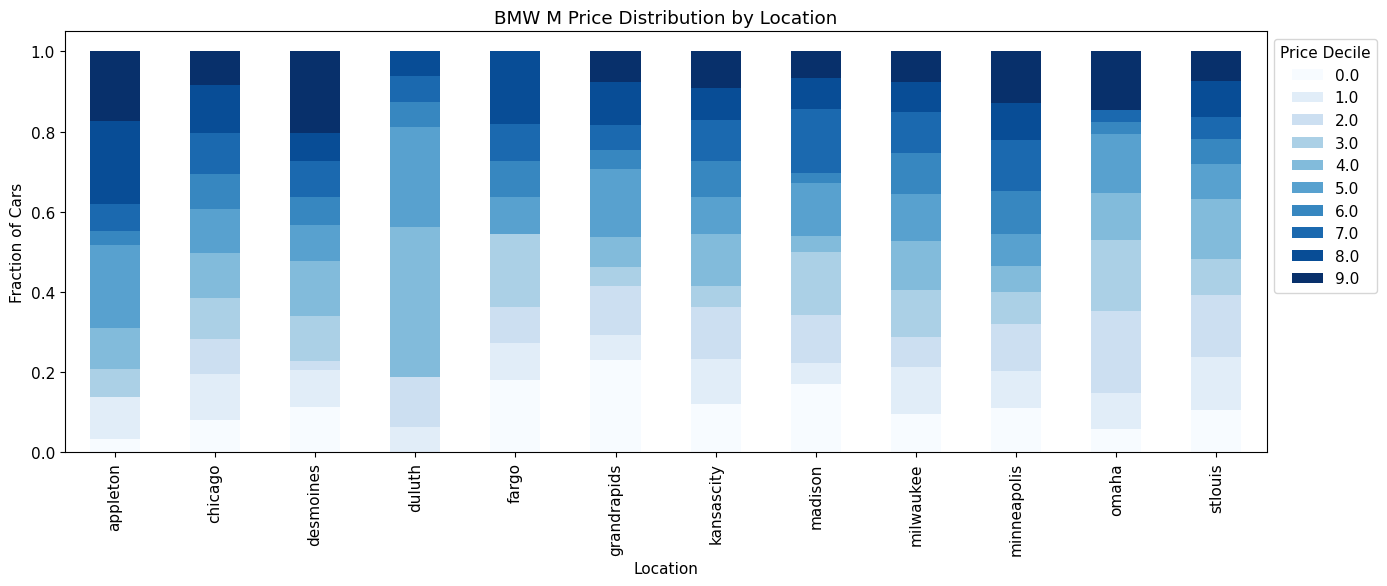

In [130]:
# Build a plot that shows the pattern by location. If one location skews high or low for price
# or has a concentration of cars in a particular decile, we should be able to see it in the plot

fraction_distribution_bmw.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Blues')
plt.title("BMW M Price Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Fraction of Cars")
plt.legend(title="Price Decile", bbox_to_anchor=(1,1 ), loc='upper left')
plt.tight_layout()
fig.savefig("figures/bmw_m_price_distribution_by_location.png", dpi=300, bbox_inches='tight')
plt.show()


Now repeat the analysis for your second make/model.

In [131]:
# Here's one code cell, but create what you need for the work.

toyota_camry = listings_subset[listings_subset["model"] == "camry"].copy()
toyota_camry['price_decile'] = pd.qcut(toyota_camry['price'], 10, labels=False)
price_distribution_camry = toyota_camry.groupby(['location', 'price_decile'], observed=True).size().unstack(fill_value=0)
print(f"\nToyota Camry \n{price_distribution_camry}")


Toyota Camry 
price_decile  0.0  1.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  9.0
location                                                      
appleton       10    2    7    3    1    5    6    3    3    8
chicago       149  216  222  215  245  217  205  169  173  142
desmoines      13    6    8    7    5    8    9   11   37   10
duluth         16   10    5    5    7    6    5    5    3   17
fargo           7    4    2    0    2    2    1   11   19    1
grandrapids     9    6    5    6    6   14   14   27    6    4
kansascity     74   15   21   25   21   29   20   18   20   30
madison        17   18   22   20   16   34   22   23   16   18
milwaukee      44   45   40   39   28   42   49   53   33   21
minneapolis   124  101  119  115  107   94   90  115  141  168
omaha           5    4   12   12    5    9    9    9    9   17
stlouis        35   22   18   26   34   28   25   28   20   34


In [132]:
fraction_distribution_camry = price_distribution_camry.div(price_distribution_camry.sum(axis=1), axis=0)
print("\nToyota Camry - Fraction of vehicles per price decile by city:\n")
print(fraction_distribution_camry)


Toyota Camry - Fraction of vehicles per price decile by city:

price_decile       0.0       1.0       2.0       3.0       4.0       5.0  \
location                                                                   
appleton      0.208333  0.041667  0.145833  0.062500  0.020833  0.104167   
chicago       0.076293  0.110599  0.113671  0.110087  0.125448  0.111111   
desmoines     0.114035  0.052632  0.070175  0.061404  0.043860  0.070175   
duluth        0.202532  0.126582  0.063291  0.063291  0.088608  0.075949   
fargo         0.142857  0.081633  0.040816  0.000000  0.040816  0.040816   
grandrapids   0.092784  0.061856  0.051546  0.061856  0.061856  0.144330   
kansascity    0.271062  0.054945  0.076923  0.091575  0.076923  0.106227   
madison       0.082524  0.087379  0.106796  0.097087  0.077670  0.165049   
milwaukee     0.111675  0.114213  0.101523  0.098985  0.071066  0.106599   
minneapolis   0.105622  0.086031  0.101363  0.097956  0.091141  0.080068   
omaha         0.054945  

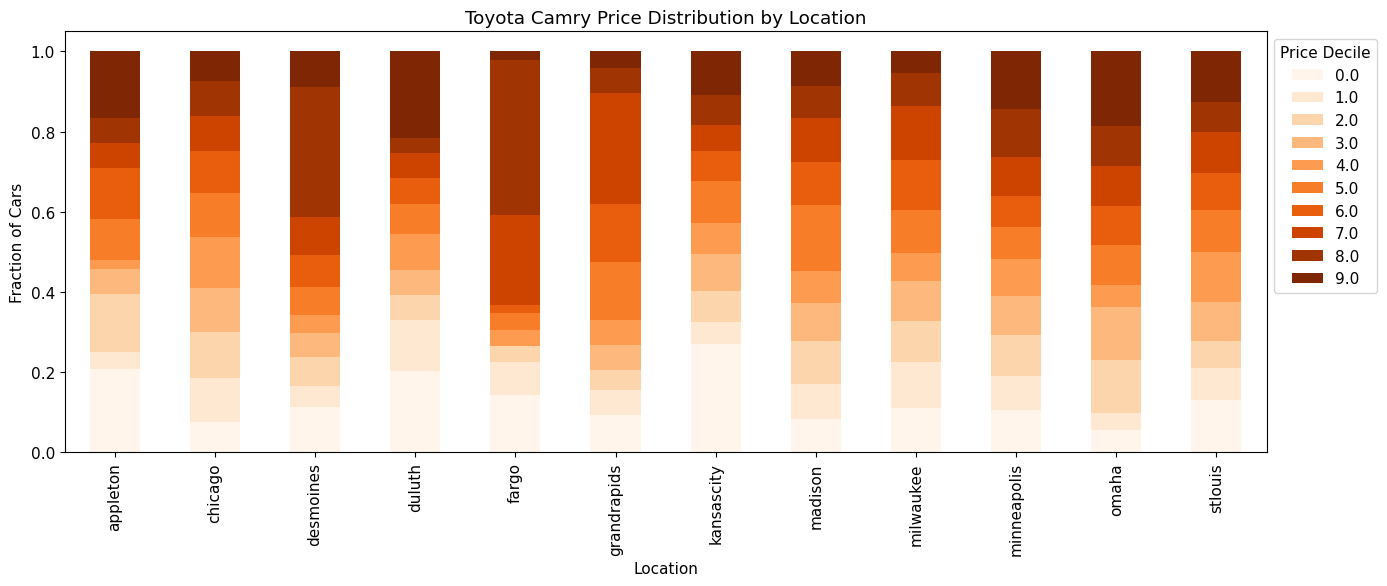

In [133]:
fraction_distribution_camry.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Oranges')
plt.title("Toyota Camry Price Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Fraction of Cars")
plt.legend(title="Price Decile", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
fig.savefig("figures/toyta_camry_price_distribution_by_location.png", dpi=300, bbox_inches='tight')
plt.show()

Q: What do you notice about the distribution of cars within price deciles across the locations for your first model? 

A: <!-- Your reply here. -->BMW M prices are all over the place, depending on the city. Some cities like Appleton have mostly expensive BMWs, while cities like Duluth have mostly cheap ones.  A few cities, like Fargo and Kansas City, have more balanced distributions across all price levels. This shows that BMW M shopping is very location dependent, and you'd find completely different price ranges depending on which city you search in.

Q: What about for the second model?

A: <!-- Your reply here. --> Toyota Camrys are pretty much the same price everywhere. All the cities look very similar in the chart, with only tiny differences between them.  Every location has a similar gradual pattern from cheap to expensive cars, with only small differences between cities. While Des Moines and Fargo have slightly more expensive Camrys and Chicago has slightly more affordable ones, these differences are tiny compared to the huge variations we saw with BMW Ms. This demonstrates that Camrys are true commodity vehicles with standardized market pricing regardless of location.


---


### Part 4: Reflection

Write a brief reflection on your analysis:

Q: What part of this analysis was most difficult?  

A: <!-- Your answer here -->  Part 2, which involved grouping operations and working with categorical data, was the most difficult for me. Specifically, finding the three-year range with the most vehicles for both make/models was tricky. I initially tried to calculate it manually in a more step-by-step approach like I do on LeetCode, but it was hard to get right. Eventually, I discovered the rolling(3).sum() method, which made it much easier.
Working with deciles was also a bit confusing at first. I knew that deciles divide data into 10 parts, but I wasn’t sure how to calculate the fraction of vehicles in each decile for every location. It took some time to understand and implement correctly


Q: How long did this assignment take you?  

A: <!-- Your answer here -->I think it took around five hours. Part 1 was fairly easy, and the other sections were manageable. I spent most of my time on the challenging parts mentioned above and also deciding which visualization to use, such as line graphs, scatter plots, or stacked bar charts, for the distribution analysis.

Q: If you were advising someone on buying one of these vehicles, what insights would you share based on your analysis?  

A: <!-- Your answer here -->  I would tell someone that Toyota Camrys are widely available across Midwestern cities, their prices are generally consistent, and mileage varies moderately. Choosing a car in a larger city like Chicago or Minneapolis may give more options and slightly more predictable prices, while smaller cities might have fewer listings but some very good deals. Always check the mileage, as lower-mileage cars tend to be priced higher but may last longer.
